# Segmentation 3: inspect the peaks (1 degree mosaicity)

Checks of the segmented peaks: how many per translation, the sinogram they
form, and where the rotation axis is.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from simtools import io, paths, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_1p0deg"
colf = io.read_peaks(paths.peaks_path(SAMPLE))
print(f"{colf.nrows} peaks")

Reading your columnfile in hdf format
895177 peaks


## Peaks per translation

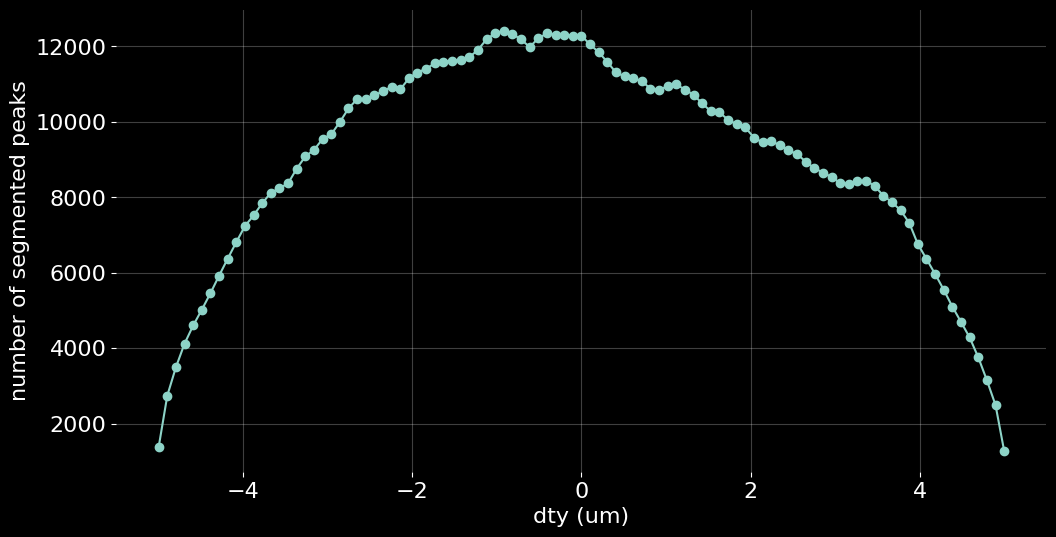

In [3]:
dty_centers, npks = np.unique(colf.dty.round(6), return_counts=True)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(dty_centers, npks, "o-")
ax.set_xlabel("dty (um)")
ax.set_ylabel("number of segmented peaks")
ax.grid(True, alpha=0.25)
plot.despine(ax)
plt.show()

## Sinogram of the peaks and the rotation axis
The sample is centred on the rotation axis at dty = 0 in the simulation, so the centre of mass of the summed sinogram should be close to 0.

centre of mass of the sinogram: dty = -0.0635 um (-0.622 translation steps)


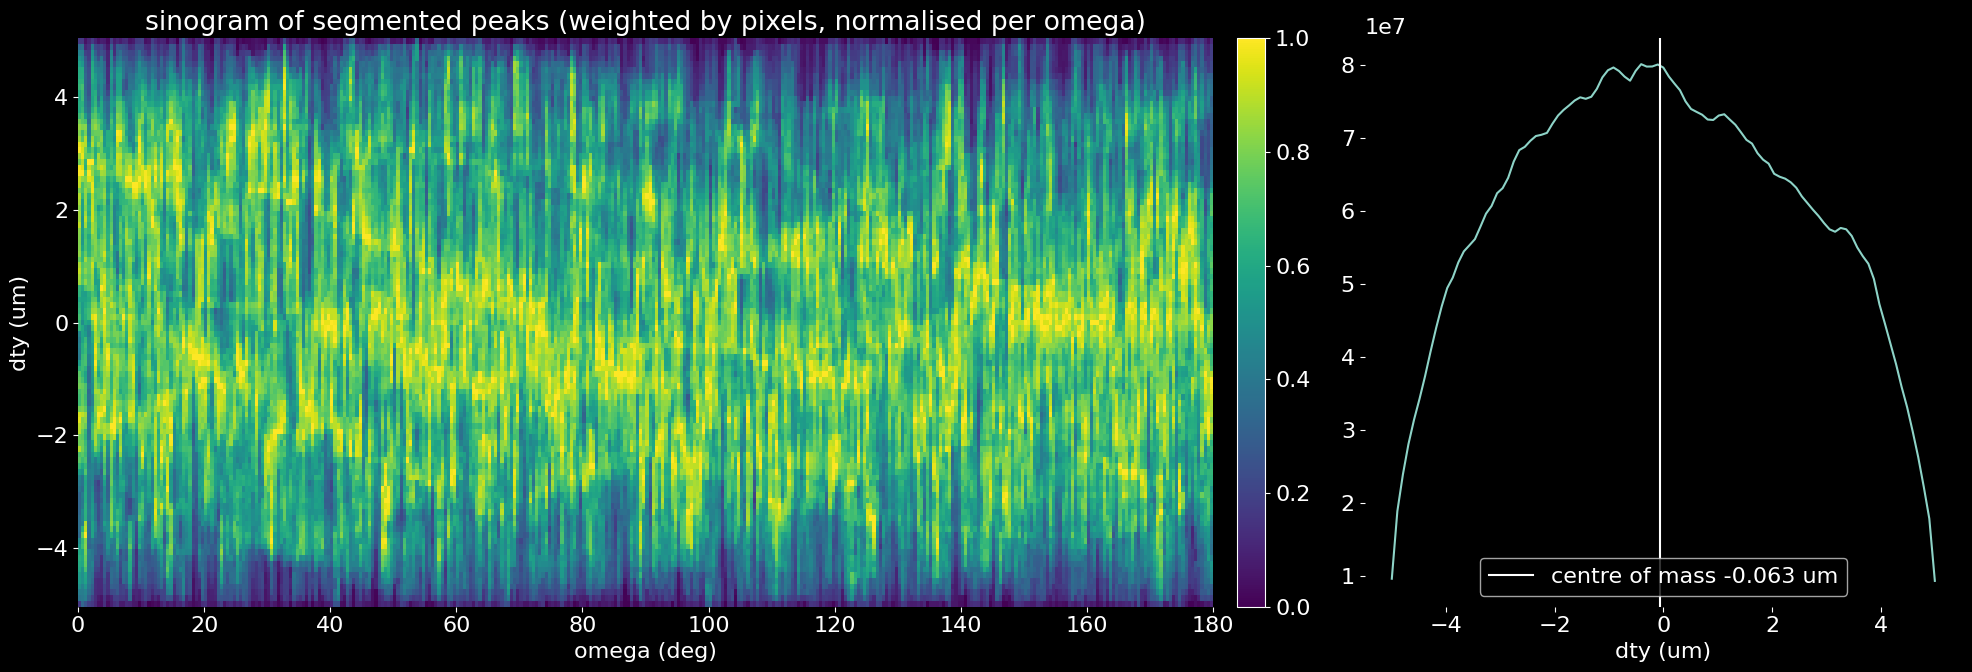

In [4]:
dty_step = dty_centers[1] - dty_centers[0]
dty_bins = np.concatenate([dty_centers - dty_step / 2, [dty_centers[-1] + dty_step / 2]])
ome_centers = np.unique(colf.omega.round(3))
ome_step = ome_centers[1] - ome_centers[0]
ome_bins = np.concatenate([ome_centers - ome_step / 2, [ome_centers[-1] + ome_step / 2]])

sino, _, _ = np.histogram2d(colf.dty, colf.omega, bins=(dty_bins, ome_bins), weights=colf.Number_of_pixels)
profile = sino.sum(axis=1)
rotation_axis_com = np.sum(profile * dty_centers) / np.sum(profile)
print(f"centre of mass of the sinogram: dty = {rotation_axis_com:.4f} um ({rotation_axis_com / dty_step:.3f} translation steps)")

fig, ax = plt.subplots(1, 2, figsize=(20, 7), width_ratios=[2, 1])
im = ax[0].pcolormesh(ome_centers, dty_centers, sino / sino.max(axis=0, keepdims=True), shading="nearest")
ax[0].set_xlabel("omega (deg)")
ax[0].set_ylabel("dty (um)")
ax[0].set_title("sinogram of segmented peaks (weighted by pixels, normalised per omega)")
fig.colorbar(im, ax=ax[0], fraction=0.03, pad=0.02)
ax[1].plot(dty_centers, profile)
ax[1].axvline(rotation_axis_com, c="w", label=f"centre of mass {rotation_axis_com:.3f} um")
ax[1].set_xlabel("dty (um)")
ax[1].legend()
plot.despine(ax)
plt.tight_layout()
plt.show()

## Peaks on a frame

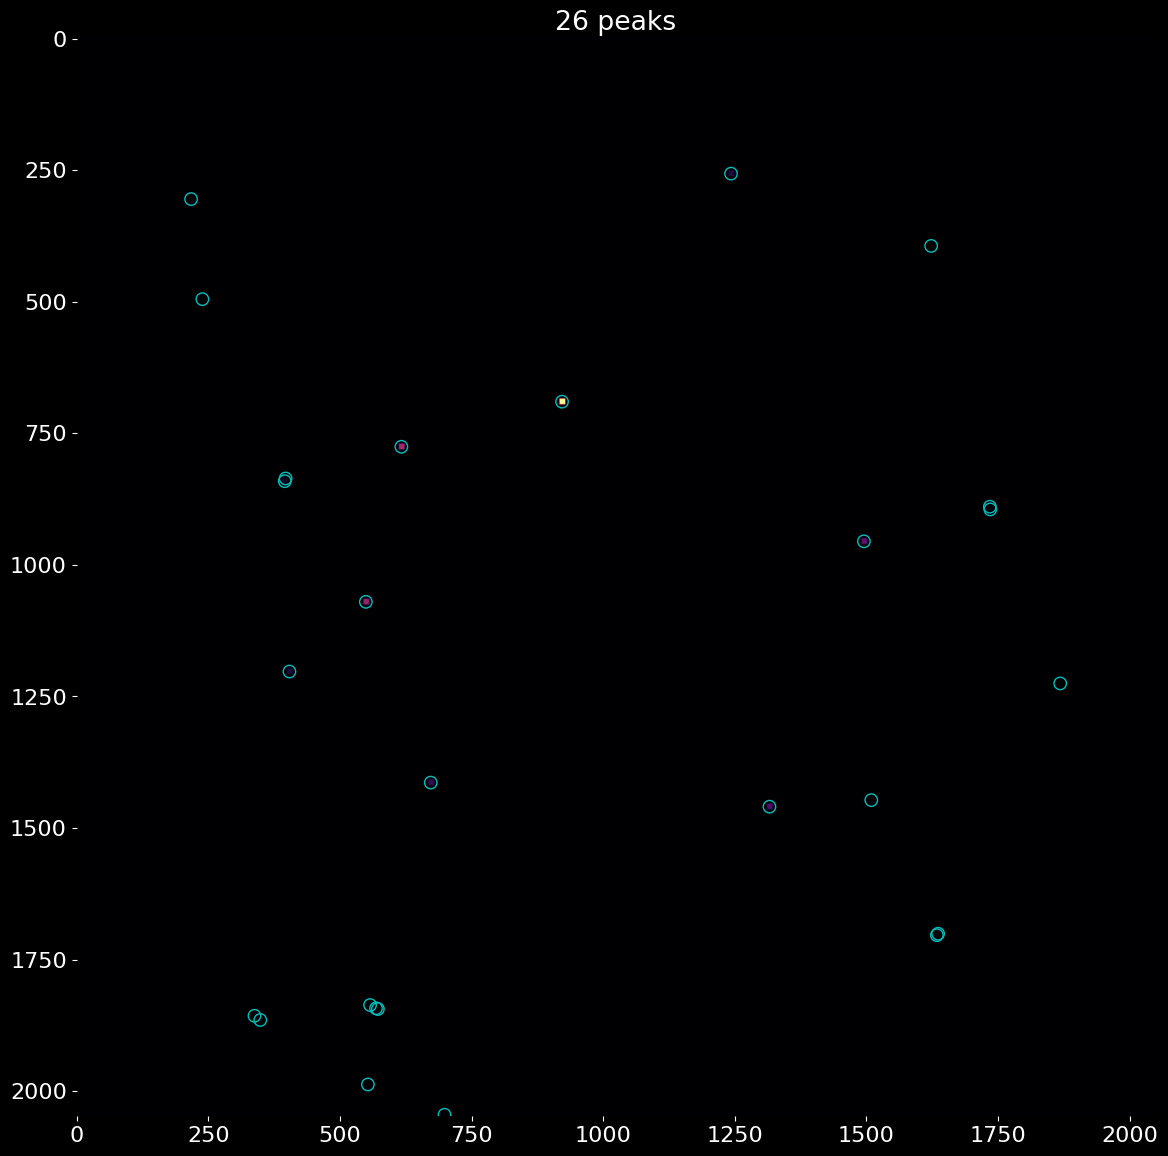

In [5]:
files = io.scan_files(SAMPLE)
i_trans, i_omega = len(files) // 2, 0
with io.SparseScan(files[i_trans]) as scan:
    frame = scan.frame(i_omega)
    ostep = scan.omega[1] - scan.omega[0]
    m = np.isclose(colf.dty, scan.dty, atol=1e-4) & np.isclose(colf.omega, scan.omega[i_omega] + ostep / 2)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
ax.imshow(maximum_filter(np.log10(frame + 1), size=9), cmap="inferno")  # max-filtered for display
ax.scatter(colf.fc[m], colf.sc[m], marker="o", facecolors="none", edgecolors="c", s=80)
ax.set_title(f"{m.sum()} peaks")
plot.despine(ax)
plt.show()